In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../datasets/household_power_consumption.txt", sep=';', na_values=['?'])
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [163]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
df['DateOnly'] = df['Date'].dt.date
df_grouped = df.drop(columns='Time').groupby(['DateOnly', 'Hour']).mean().reset_index()
df_grouped.head()

,DateOnly,Hour,Date,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,17,2006-12-16,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
1,2006-12-16,18,2006-12-16,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2,2006-12-16,19,2006-12-16,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
3,2006-12-16,20,2006-12-16,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
4,2006-12-16,21,2006-12-16,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [164]:
df_grouped.shape

(34589, 10)

### Only using data of 25 days

In [165]:
df = df_grouped[7:24*25+7]
df_raw = df.copy()
df.head()

,DateOnly,Hour,Date,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
7,2006-12-17,0,2006-12-17,1.882467,0.102433,240.961833,8.126667,0.0,0.466667,0.000000
8,2006-12-17,1,2006-12-17,3.349400,0.136933,240.448333,14.246667,0.0,25.233333,0.000000
9,2006-12-17,2,2006-12-17,1.587267,0.078233,245.818667,6.870000,0.0,0.566667,0.000000
10,2006-12-17,3,2006-12-17,1.662200,0.079533,244.513500,7.206667,0.0,0.766667,0.000000
11,2006-12-17,4,2006-12-17,2.215767,0.093467,243.855500,9.333333,0.0,0.566667,8.883333


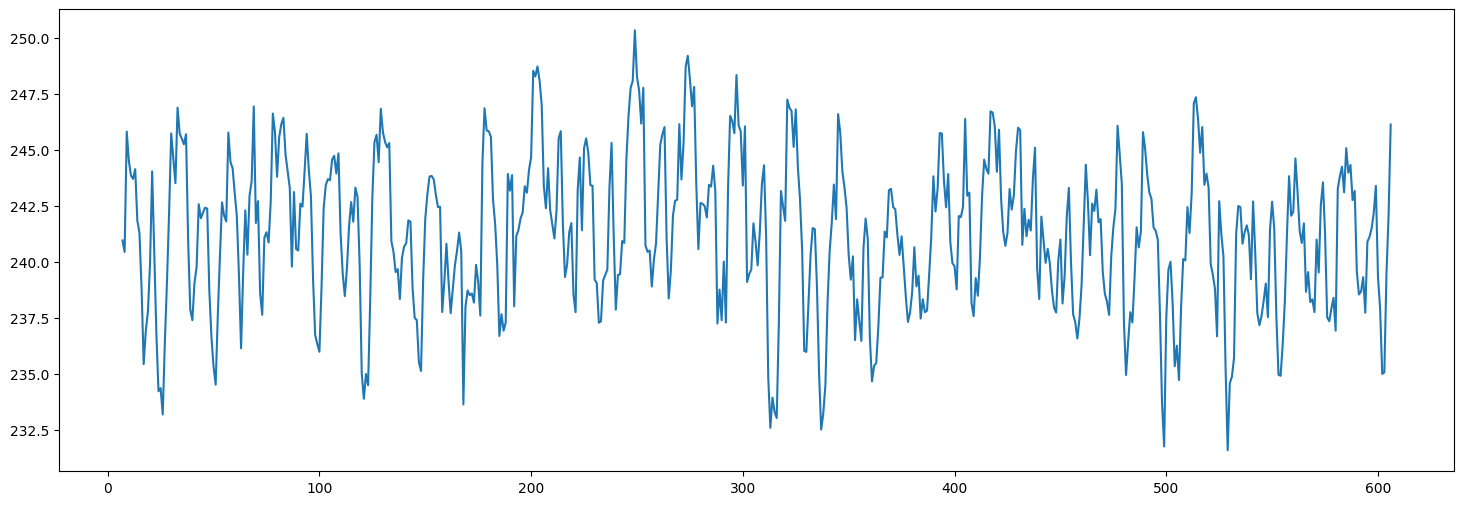

In [166]:
plt.figure(figsize=(18, 6))
plt.plot(df['Voltage'])

### Smoothing using rolling mean

In [167]:
# make each numeric column smooth by rolling mean
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()
df.head(5)

/tmp/ipykernel_100448/2014813997.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()


,DateOnly,Hour,Date,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
7,2006-12-17,0.0,2006-12-17,1.882467,0.102433,240.961833,8.126667,0.0,0.466667,0.000000
8,2006-12-17,0.5,2006-12-17,2.615933,0.119683,240.705083,11.186667,0.0,12.850000,0.000000
9,2006-12-17,1.0,2006-12-17,2.273044,0.105867,242.409611,9.747778,0.0,8.755556,0.000000
10,2006-12-17,1.5,2006-12-17,2.120333,0.099283,242.935583,9.112500,0.0,6.758333,0.000000
11,2006-12-17,2.0,2006-12-17,2.139420,0.098120,243.119567,9.156667,0.0,5.520000,1.776667


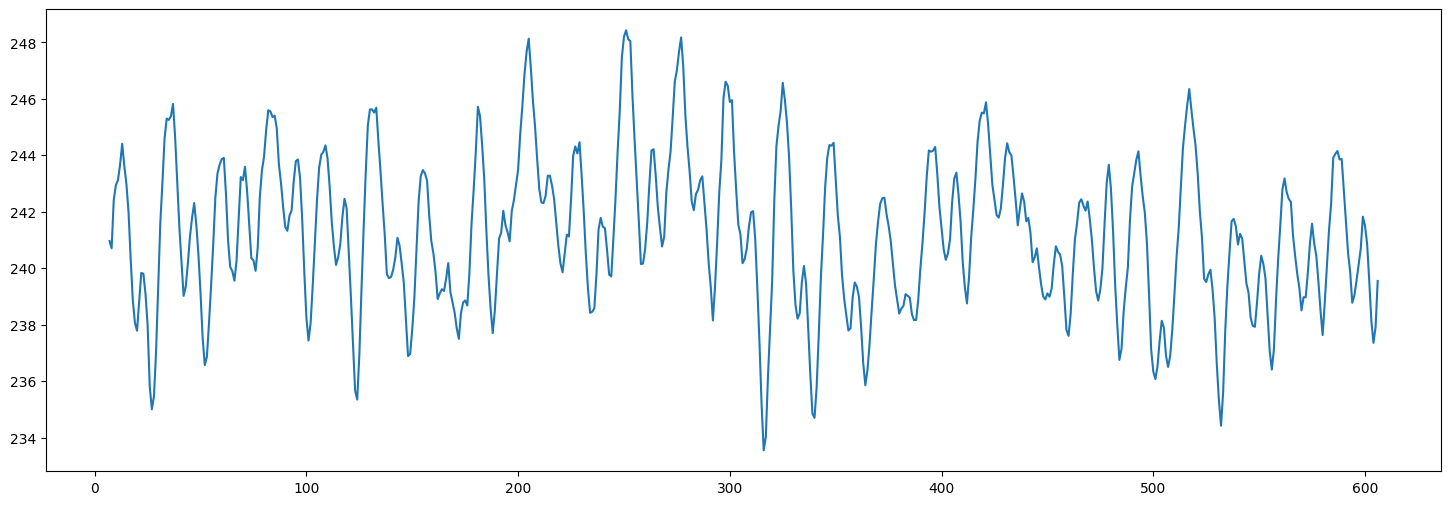

In [168]:
plt.figure(figsize=(18, 6))
plt.plot(df['Voltage'])

In [169]:
df.shape, df.dtypes

((600, 10),
 DateOnly                         object
 Hour                            float64
 Date                     datetime64[ns]
 Global_active_power             float64
 Global_reactive_power           float64
 Voltage                         float64
 Global_intensity                float64
 Sub_metering_1                  float64
 Sub_metering_2                  float64
 Sub_metering_3                  float64
 dtype: object)

In [170]:
TOTAL_POINTS = len(df)
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = TOTAL_POINTS // PERIOD
FEATURES = 7
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 25 x 24 x 7


In [171]:
data = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']][:PERIOD*TIME].values

tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(25, 24, 7)

In [172]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 24, 7)
Test tensor shape: (5, 24, 7)


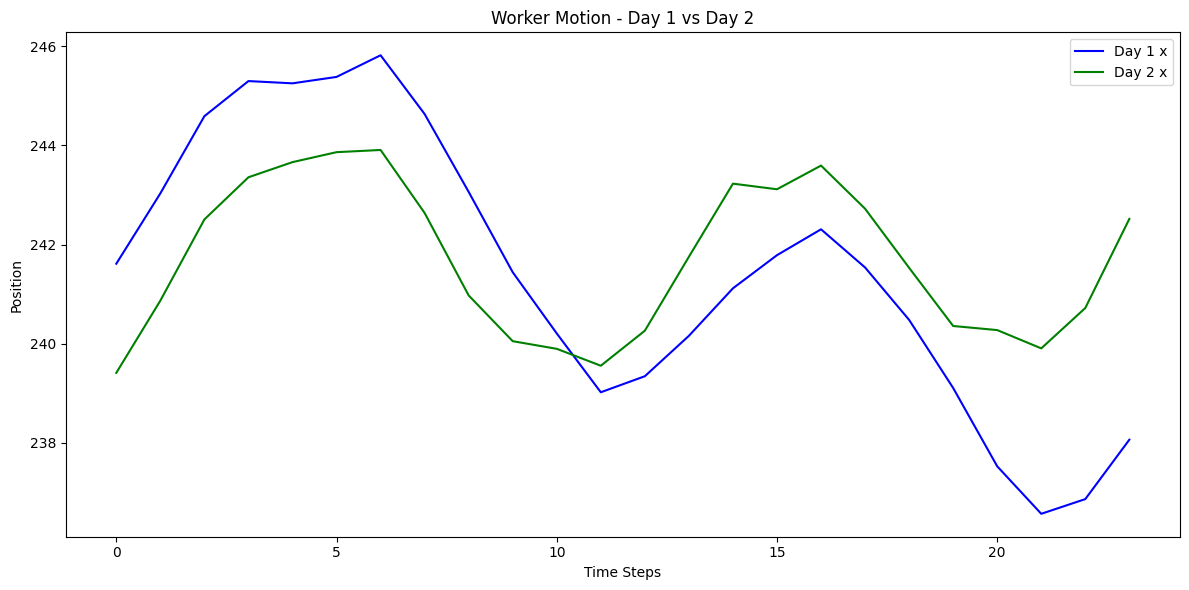

In [184]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 2], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 2], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [174]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (24, 2)
Feature factors shape: (7, 2)


In [175]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 24, 7)
Reconstructed tensor shape: (20, 24, 7)


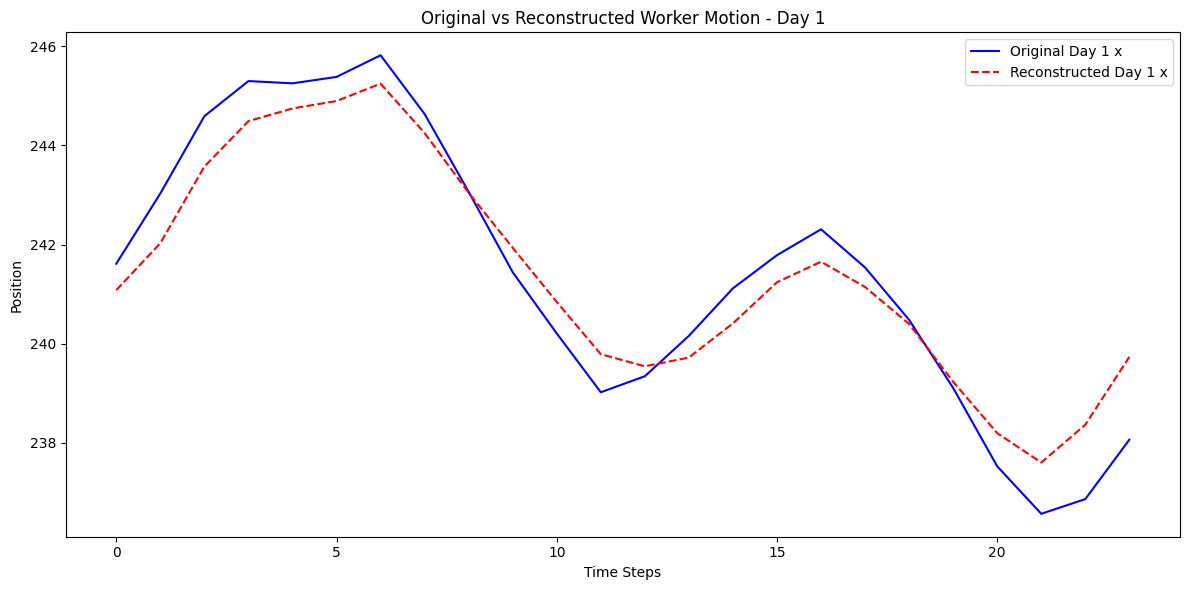

In [183]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 2], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 2], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [177]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

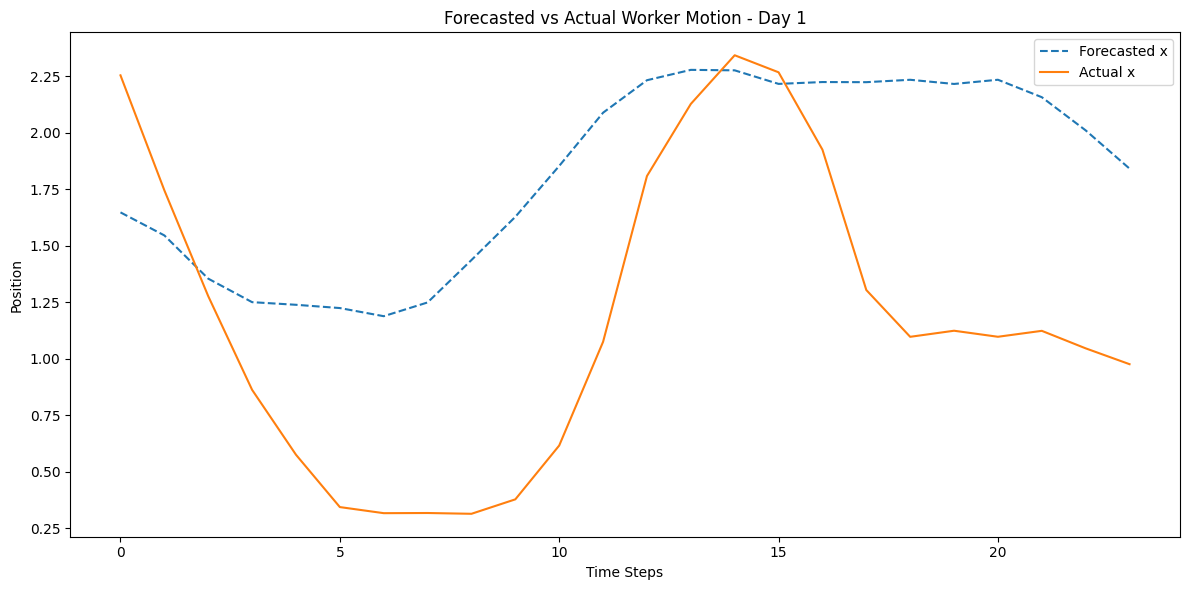

In [178]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

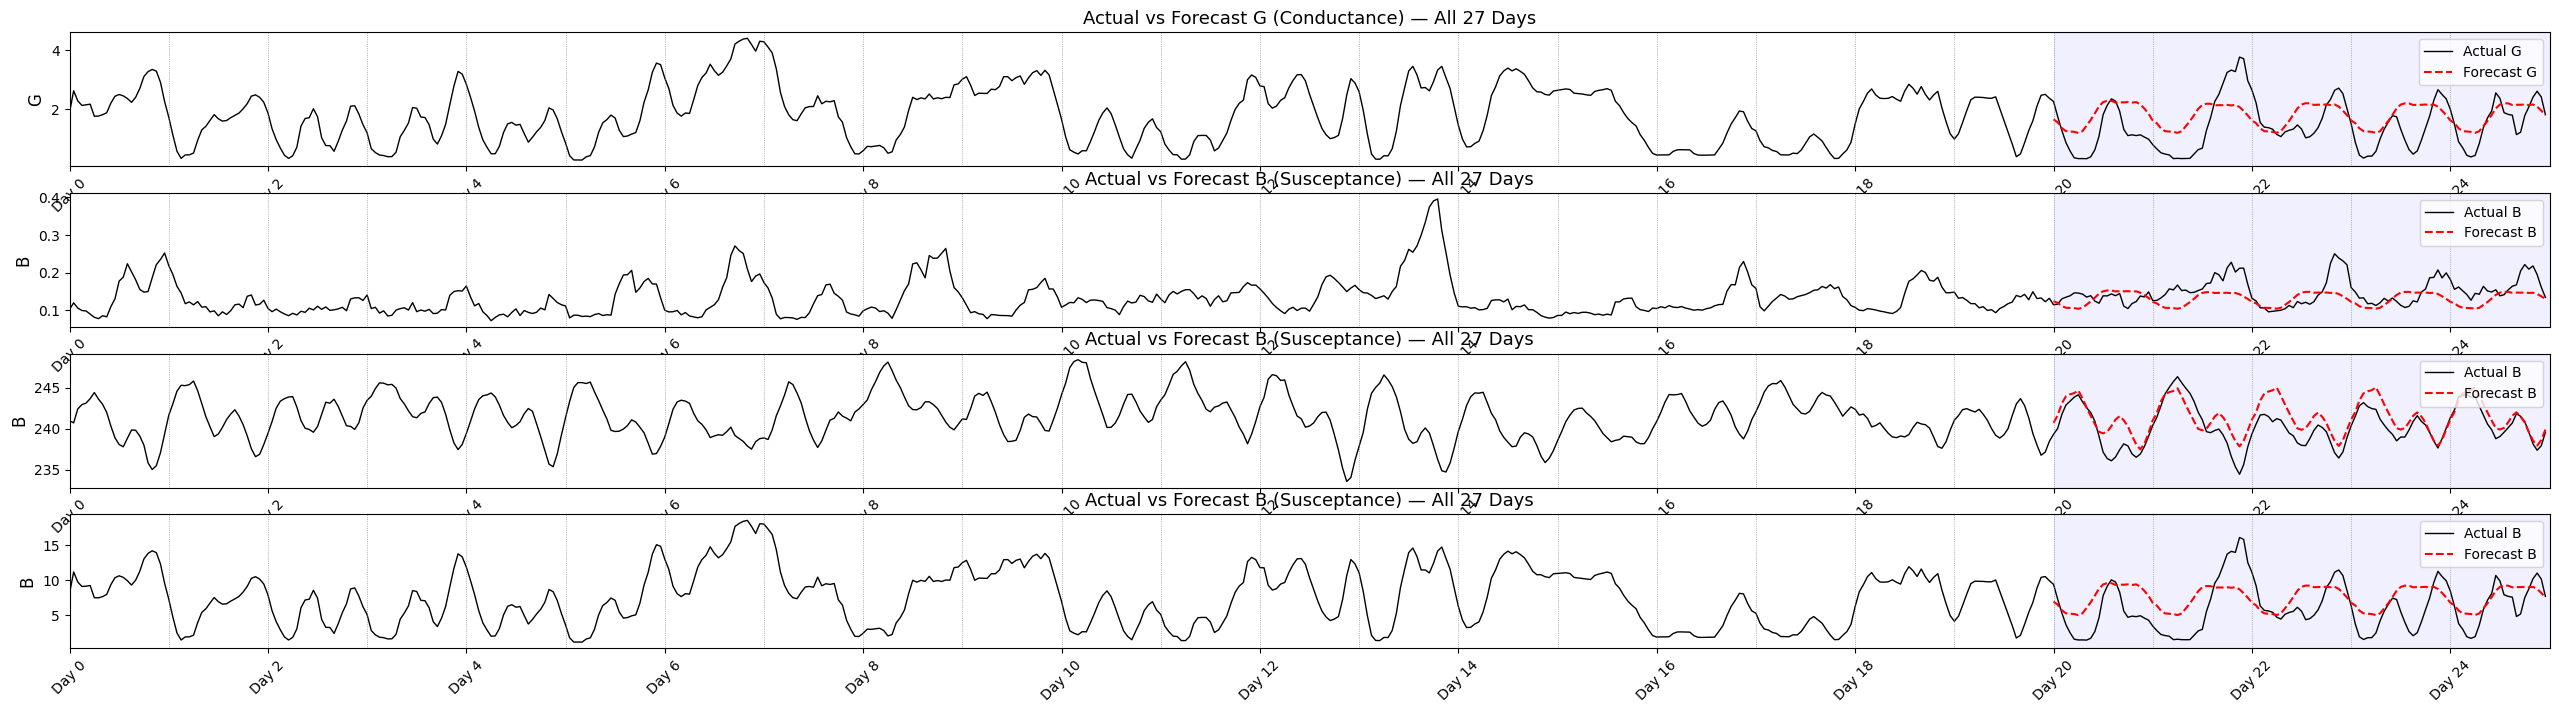

In [179]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

plt.figure(figsize=(32, 8))

plt.subplot(4, 1, 1)
plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('G', fontsize=12)
plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 2)
plt.plot(x, full_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 3)
plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 4)
plt.plot(x, full_series[:, 3], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 3], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

# plt.xlabel('Time Steps', fontsize=12)
# plt.tight_layout()
# plt.show()

Test series shape: (120, 7)
Forecast series shape: (120, 7)
x shape: (120,)


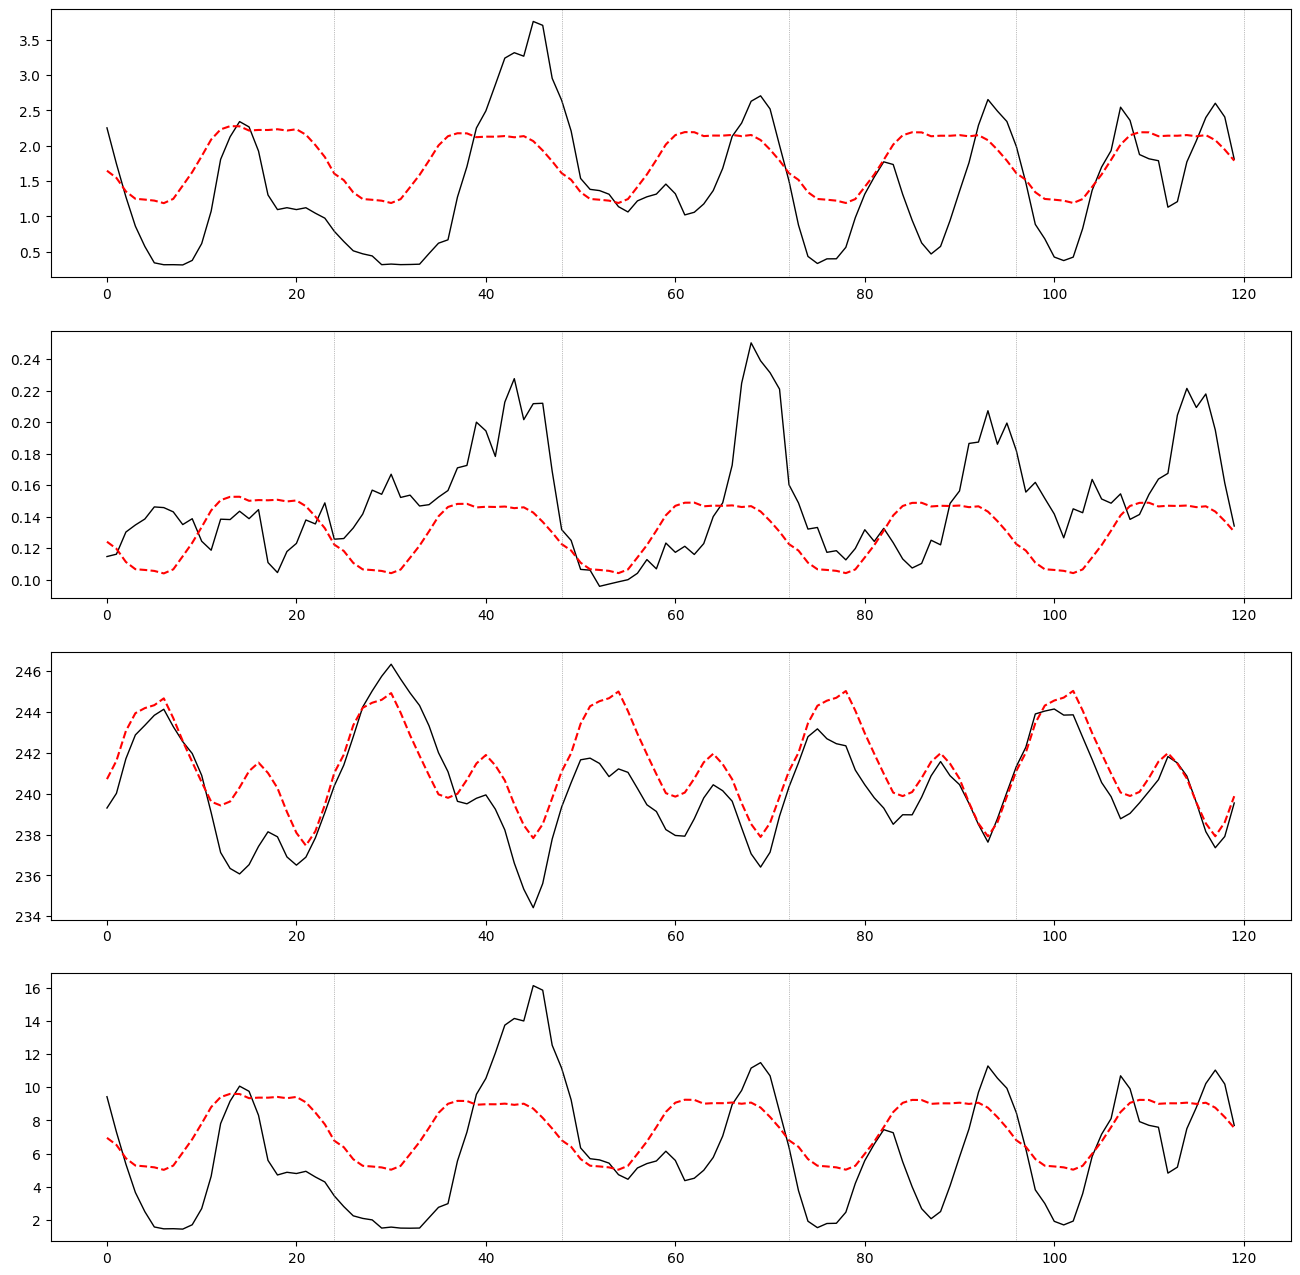

In [180]:
# Flatten full tensor and forecast tensor into time series
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)
plt.figure(figsize=(16, 16))

print(f"Test series shape: {test_series.shape}")
print(f"Forecast series shape: {forecast_series.shape}")
print(f"x shape: {x.shape}")

plt.subplot(4, 1, 1)
plt.plot(test_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 2)
plt.plot(test_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 3)
plt.plot(test_series[:, 2], 'k-', lw=1, label='Actual C')
plt.plot(forecast_series[:, 2], 'r--', lw=1.5, label='Forecast C')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 4)
plt.plot(test_series[:, 3], 'k-', lw=1, label='Actual D')
plt.plot(forecast_series[:, 3], 'r--', lw=1.5, label='Forecast D')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)


In [181]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((480, 7), (120, 7))

In [182]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score

r2_a = r2_score(test_series[:, 0], forecast_series[:, 0])
r2_b = r2_score(test_series[:, 1], forecast_series[:, 1])
r2_c = r2_score(test_series[:, 2], forecast_series[:, 2])
r2_d = r2_score(test_series[:, 3], forecast_series[:, 3])
# r2_e = r2_score(test_series[:, 4], forecast_series[:, 4])
# r2_f = r2_score(test_series[:, 5], forecast_series[:, 5])
# r2_g = r2_score(test_series[:, 6], forecast_series[:, 6])

r2_scores = {
    'Col 1': r2_a,
    'Col 2': r2_b,
    'Col 3': r2_c,
    'Col 4': r2_d,
    # 'Col 5': r2_e,
    # 'Col 6': r2_f,
    # 'Col 7': r2_g
}

r2_scores_df = pd.DataFrame(list(r2_scores.items()), columns=['Column', 'R² Score'])
print(r2_scores_df)

  Column  R² Score
0  Col 1  0.104000
1  Col 2 -0.214247
2  Col 3  0.491503
3  Col 4  0.122101
